# 计算机图形学笔记

20251114

## 第一章 绪论

### 1. 图像学和图形学的区别

### 2. 走样的原因
  
  用离散量表示连续量引起的失真.
### 3. 反走样的概念
  
  减少或消除因走样造成的阶梯形或闪烁的效果的方法称为反走样.反走样技术有:

  1. 前滤波:以较高的分辨率显示对象
  2. 后滤波:加权区域取样

### 4. 直线的扫描转换算法

对直线进行光栅化时,需要在显示器有限个象素中,确定最佳逼近该支线的一组象素,并且按照扫描线顺序,对这些象素进行写操作.这个过程称为显示器绘制直线或直线的扫描转换.

直线的扫描转换算法有:

- DDA算法
- 中点线算法
- Bresenham算法
  
#### 4.1 DDA算法

考虑到增量计算较快的原因，所以没有直接使用 y = kx+b的方法直接计算每个点的横纵坐标。而是使用 y(i) = y(i-1)+k △x  当△x  = 1的时候  y(i) = y(i-1)+k,这样只需要加法运算就可以求出每次的y值。
#### 4.2 Bresenham算法
  
  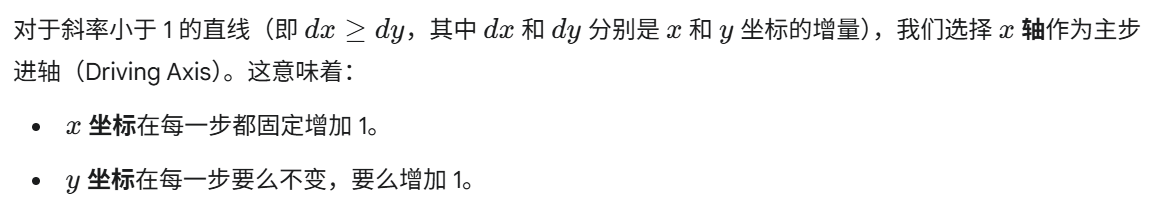

  以此种情况(即dx>dy)为例,每一步x坐标递增之后,y坐标要么不变(水平向右移动),要么以相同幅度递增(对角线方向移动).选择的规则如下:

  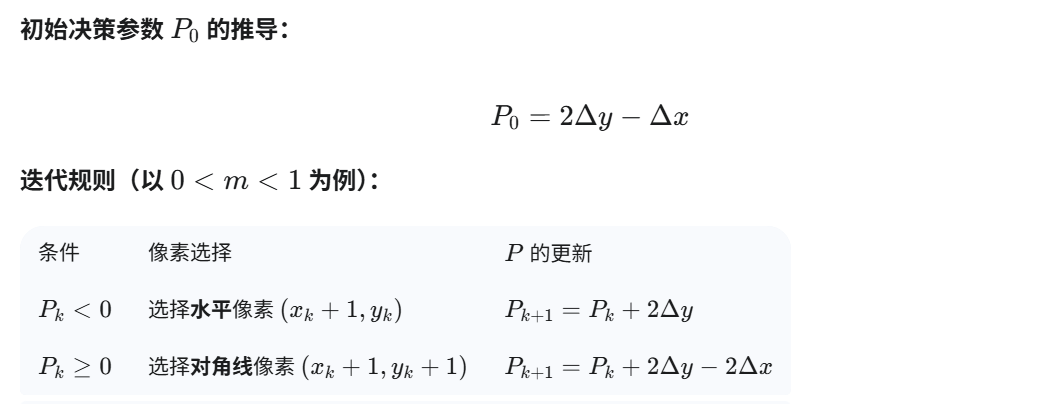

  **注:为了方便计算,可以提前算出两个方向(向右或向右上的)增量.**

  

## 第二章 颜色模型

### 1. 设备无关与设备相关
   - 设备无关的颜色模型:基于人眼对色彩感知的度量建立的数学模型,主要用于计算和测量.
   - 设备相关的颜色模型:以RGB模型为例,一组确定的RGB数值在一个液晶屏上显示,最终会作用到三色LED的电压上.这样一组值在不同设备上解释时,得到的颜色可能不同.
  
### 2. 设备相关与无关的模型例子
  在设备相关,不相关的颜色模型间互相转换,一般是以RGB和CIEXYZ作为桥梁进行的.
  
  - 相关:RGB,CMY,CMYK,HSV
  - 不相关: CIEXYZ

### 3. RGB模型和CMY模型之间的比较

| 比较维度 | RGB (Red, Green, Blue) | CMY (Cyan, Magenta, Yellow) |
| :--- | :--- | :--- |
| **物理原理** | 加色法 (Additive Color) | 减色法 (Subtractive Color) |
| **媒介本质** | 光 (发光体) | 颜料 / 油墨 (吸光物体) |
| **基础底色** | 黑色 (无光) | 白色 (全反射，如白纸) |
| **混合方向** | 颜色越加越亮 | 颜色越加越暗 |
| **最大混合** | R + G + B = 白色 | C + M + Y = 黑色 (理论值) |
| **主要应用** | 显示器、投影仪、相机、手机屏幕 | 打印机、胶印印刷、绘画 |印印刷、绘画、印刷、绘画

## 第三章 物体表示(1)-多边形表示:OBJ,BRep和半边数据结构

### 1.坐标系区别

- 世界坐标系: **场景参照坐标系,一个场景只有一个世界坐标系.** 是用于定义物体在场景中的位置.是一个大范围的参考,用来确定所有物体如何放置在这个虚拟世界中.

- 建模坐标系: **描述单个物体的形状,尺寸所采用的坐标系.** 是针对单个物体的.每个物体都是在它子集的坐标系中被创建和编辑的,就像是每件家具有自己的小平面图.这有助于设计者单独操作和调整每个模型,而不必担心其它模型或整个世界的坐标.

### 2.多边形表示方法:OBJ格式

保存: 1.几何信息.2.纹理信息.3.光线信息.

- 多边形表示的优点:
  + 表示简单.
  + 可以表示具有任意拓扑的物体.
  + 可以表示具有丰富细节的物体.
  + 大部分图形硬件支持多边形物体的加速绘制.
 
- 多边形表示的不足:
  + 逼近表示,难以满足交互时放大需求.
  + 难以用传统方法编辑物体外形.
  + 缺乏解析表达式,几何属性计算困难.
  + 在表示复杂拓扑和具有丰富细节的物体时,数据量庞大,建模/编辑/绘制/存储的负担重.

### 3.BREP表示

实体的边界通常由面的并集来表示;每个面又由他所在的曲面的定义加上其边界来表示,面的边界是边的并集;而边又是由点来表示的.

**BRep是什么?**

A:网格表示数据结构.

**BRep表示的两种类型**

A:1.拓扑信息(即网格之间的关系). 2.几何信息(网格坐标在哪里,大小是多少).

### 4.半边数据结构

- 每条边被记录为两条半边,记录每条半边:
  + 起始顶点的指针.
  + 邻接面的指针.(如果为边界,填充null)
  + (逆时针方向的)下一条半边.
  + 相邻的半边.
  + 前一条半边(可选).
  
- 面:
  边界上的一条半边.

- 顶点:
  + 坐标值.
  + 指向以此为起始端点的半边.

~~~C
struct HE_edge{
    HE_vert* vert; //起始顶点的指针
    HE_edge* pair; //相邻的半边:twin
    HE_face* face; //邻接面的指针
    HE_edge* next; //逆时针方向下一条半边
};
~~~

## 第三章 物体表示(2)

## 第四章 Pipeline

### 1. Rendering Pipeline(渲染管道)

- **考点:掌握图形渲染通道的各部分和作用.**

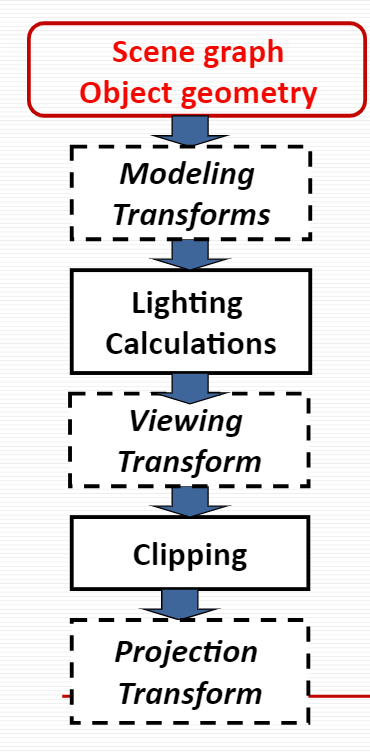

#### Modeling Transforms建模变换
    在建立或编辑三位模型时使用的.这些变换决定了模型的位置,旋转和缩放.可以理解为在虚拟世界中放置和调整模型的过程.

#### Lightning Calculations光照计算
    对场景中的所有几何图元进行照明处理,以模拟现实世界中的光照效果.过程中需要考虑以下几个光照参数:

  + 光源发射(Light source emission):涉及到光源的颜色和强度.包括如何发射光线等.例如点光源,聚光灯或环境光.
  + 表面反射率(Surface reflectance):每种材料不同的发射特性.决定了光线击中表面时反射的量,以及光线反射的方式,例如漫反射或镜面反射.
  + 大气衰减(Atmosphere attenuation):光线在通过介质时的强度减弱程度.
  + 相机响应(Camera response):模拟真实相机对光线的响应,比如光线如何被相机感光元件捕获并转换成图像.
 
    在光照计算过程中通常区分直接照明和全局照明.此处省略.

#### Viewing Transform视图变换
    视图变换的结果是:3D场景转换到视窗/相机坐标系.
